# ***Importing Libraries***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
# Removing all the warnings from output
import os
import warnings
import logging

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

logging.getLogger().setLevel(logging.ERROR)

# ***Loading Datasets***

In [2]:
train_df = pd.read_csv(f'/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv(f'/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_submission = pd.read_csv(f'/kaggle/input/comment-category-prediction-challenge/Sample.csv')

print(f"Training Data: {train_df.shape}")
print(f"Test Data: {test_df.shape}")

Training Data: (198000, 15)
Test Data: (102000, 14)


### ***Data Overview***

In [3]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


Insights

* The dataset has 198,000 rows and 15 columns covering a good mix of text, numerical, categorical and datetime data
* race, religion and gender each have only 52,577 non-null values out of 198,000, meaning roughly 73% of these columns are missing
* comment has just 1 missing value out of 198,000 which is practically nothing
* disability is a boolean column which needs to be converted to 0 and 1 before feeding it to any model
* created_date is stored as a string object instead of proper datetime, so it needs to be parsed before use
* All engagement columns like upvote, downvote, if_1 and if_2 are complete with no missing values
* The dataset has a healthy mix of data types which means we need different preprocessing strategies for numerical, categorical, text and datetime columns separately

In [5]:
train_df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


Insights

* Most comments have zero upvotes and zero downvotes as the median is 1 and 0 respectively, meaning the majority of comments go unnoticed by other users
* upvote has a max of 201 and downvote has a max of 107 but the 75th percentile is only 3 and 1 which means a very small number of comments get extreme engagement and the distribution is heavily right skewed
* if_1 has a max of 1860 and if_2 has a max of 1833 with very high standard deviations, indicating these internal features are heavily skewed with extreme outliers
* emoticon columns are mostly zero across all percentiles, meaning the vast majority of comments do not contain any emoticons
* post_id ranges from 20 to 129 with a mean of 68, suggesting comments are spread across roughly 110 different discussion threads
* label mean of 0.79 and std of 0.98 gives an early hint that the classes are not balanced, with some labels appearing much more frequently than others
* High standard deviations in if_1 and if_2 compared to their means suggest the data has extreme values that need to be handled carefully

# ***Exploratory Data Analysis (EDA)***

### ***Feature Type Identification***

In [6]:
numerical_features = ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
categorical_features = ['race', 'religion', 'gender', 'disability']
text_features = ['comment']
datetime_features = ['created_date']
target = 'label'

print(f"Numerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")
print(f"Text Feature: {text_features}")
print(f"DateTime Feature: {datetime_features}")

Numerical Features: ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
Categorical Features: ['race', 'religion', 'gender', 'disability']
Text Feature: ['comment']
DateTime Feature: ['created_date']


Insights
* The dataset has 4 types of features, numerical, categorical, text and datetime, each requiring a different preprocessing approach
* There are 8 numerical features capturing engagement and internal system signals
* race, religion, gender and disability are the 4 categorical features representing identity related information about the comment
* comment is the only text feature and is the most important column as it contains the raw content of what each user wrote
* created_date is the only datetime feature currently stored as a string object which needs to be converted before any date related operations
* label is our target variable that we need to predict

### ***Target Variable Distribution***

Target Distribution Summary:

        Count  Percentage (%)
label                        
0      114173           57.66
1       15918            8.04
2       62440           31.54
3        5469            2.76


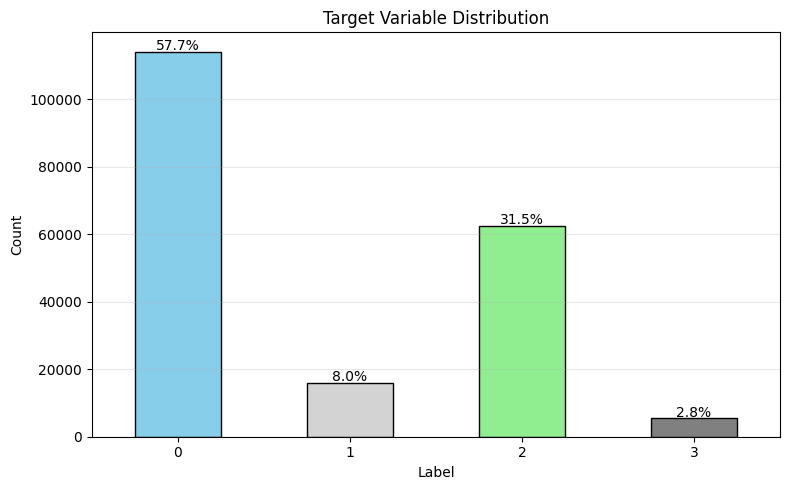

In [7]:
# Counting values
target_counts = train_df['label'].value_counts().sort_index()

# Creating a dataframe with counts and percentages
target_summary = target_counts.to_frame(name='Count')
target_summary['Percentage (%)'] = (target_counts / len(train_df) * 100).round(2)

print("Target Distribution Summary:\n")
print(target_summary)

fig, ax = plt.subplots(figsize=(8, 5))
target_counts.plot(kind='bar', color=['skyblue', 'lightgrey', 'lightgreen', 'grey'], edgecolor='black', ax=ax)
total = len(train_df)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 500, f'{v / total * 100:.1f}%', ha='center', fontsize=10)
plt.title('Target Variable Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Insights

* The target variable is highly imbalanced across the four classes.
* Label 0 dominates the dataset accounting for 57.7% which is more than half of all samples
* Label 2 is the second largest class with 31.5% making it the only other significantly represented class
* Label 1 contributes only 8.0% and Label 3 is the least represented with just 2.8% of total samples
* Label 3 is the least represented class, making up only 2.76% (5,469 samples).
* This class imbalance is a serious concern as the model may tend to favour majority classes and struggle to correctly identify minority class samples
* Weighted F1 score is the right evaluation metric here as it accounts for class imbalance by giving proportional importance to each class based on its sample size

### ***Missing Values Analysis***

 Summary of Missing values 

          Missing Count  Missing %
race             145423      73.45
religion         145423      73.45
gender           145423      73.45
comment               1       0.00

Empty Strings in Categorical Columns

race: 0 empty strings (0.00%)
religion: 0 empty strings (0.00%)
gender: 0 empty strings (0.00%)
disability: 0 empty strings (0.00%)


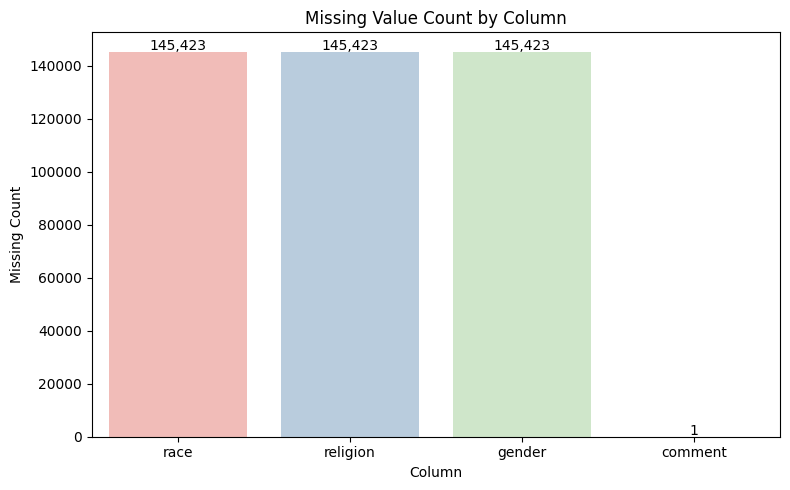

In [8]:
# Summary of missing values with percentages
missing_summary = pd.DataFrame({
    'Missing Count': train_df.isnull().sum(),
    'Missing %': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})
print(" Summary of Missing values \n")
print(missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False))

print("\nEmpty Strings in Categorical Columns\n")
# Checking empty strings in categorical columns
for col in categorical_features:
    empty_count = (train_df[col] == '').sum()
    print(f"{col}: {empty_count} empty strings ({empty_count/len(train_df)*100:.2f}%)")

# Visualisation of Missing Values by Count
missing_count = train_df.isnull().sum()
missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing_count.index, y=missing_count.values, palette='Pastel1')
plt.title('Missing Value Count by Column')
plt.xlabel('Column')
plt.ylabel('Missing Count')
for i, v in enumerate(missing_count.values):
    plt.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Insights

* race, religion and gender have about 73.45% missing values which is a large portion of the data
* This indicates that the platform only flags comments where identity related content is detected and leaves the rest as null
* The comment column is almost complete with only 1 missing value out of 198000 which is negligible
* No empty strings were found in any categorical column meaning all missing data is stored as NaN rather than blank text
* Missing information is stored as NaN rather than blank text, making it easier to handle during preprocessing

### ***Numerical Features Distribution***

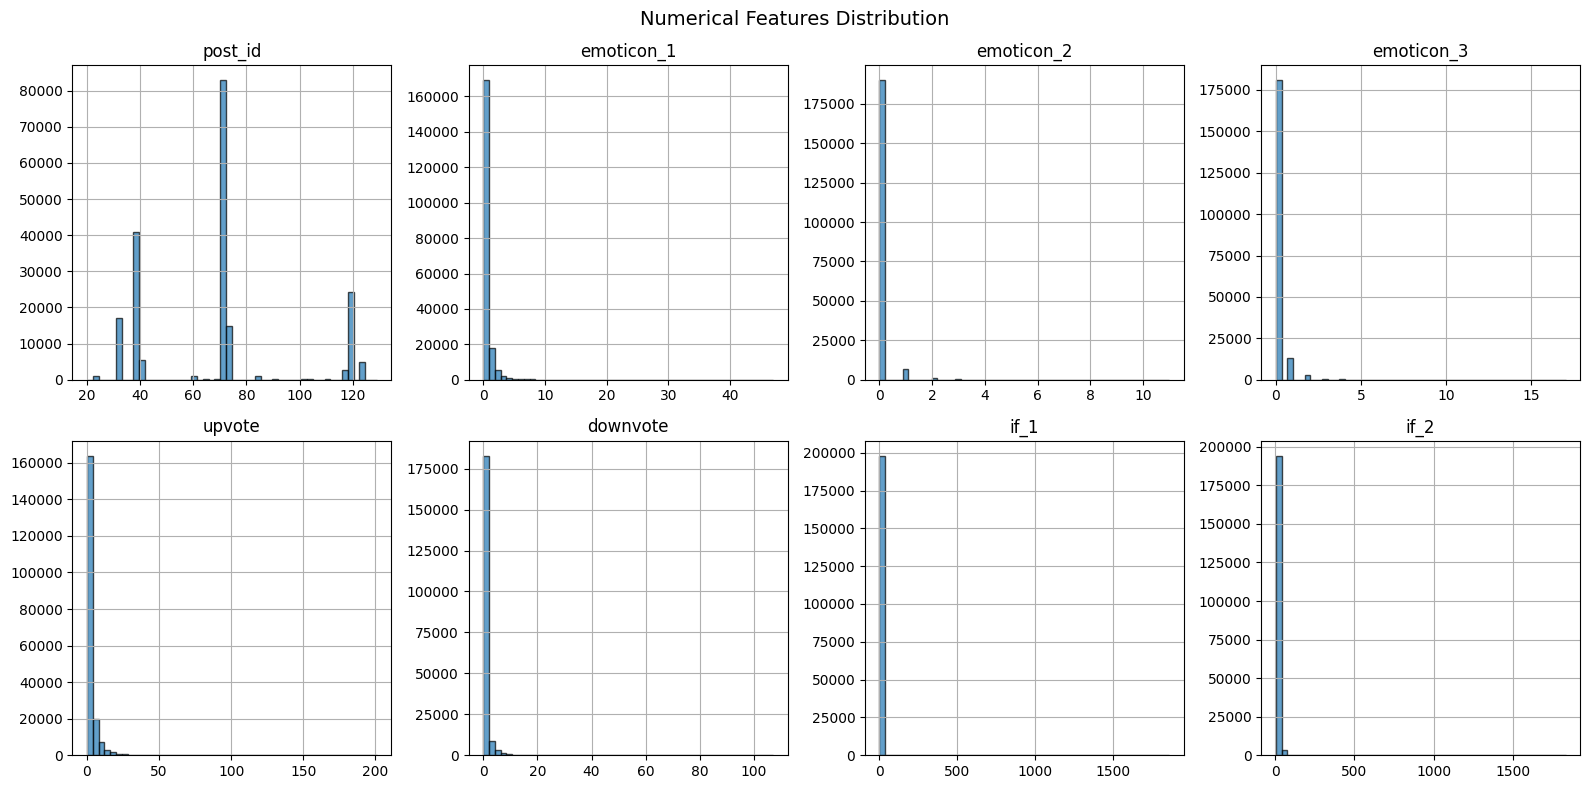

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    train_df[col].hist(bins=50, ax=axes[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('')

plt.suptitle('Numerical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

Insights

* Most numerical features are highly right-skewed, meaning a large number of values are concentrated near zero with a few extreme values.
* emoticon_1, emoticon_2 and emoticon_3 mostly contain very low counts which indicates that emoticons are rarely used in comments
* Upvotes and downvotes are also heavily skewed as most comments get very few votes while a small number receive very high engagement.
* if_1 and if_2 show strong skewness as well which means large values occur very rarely
* post_id behaves more like an identifier rather than a meaningful numerical variable as it shows a discrete distribution with only certain values appearing frequently
* Overall the distributions confirm the presence of outliers and extreme values in most numerical features

### ***Correlation Analysis***

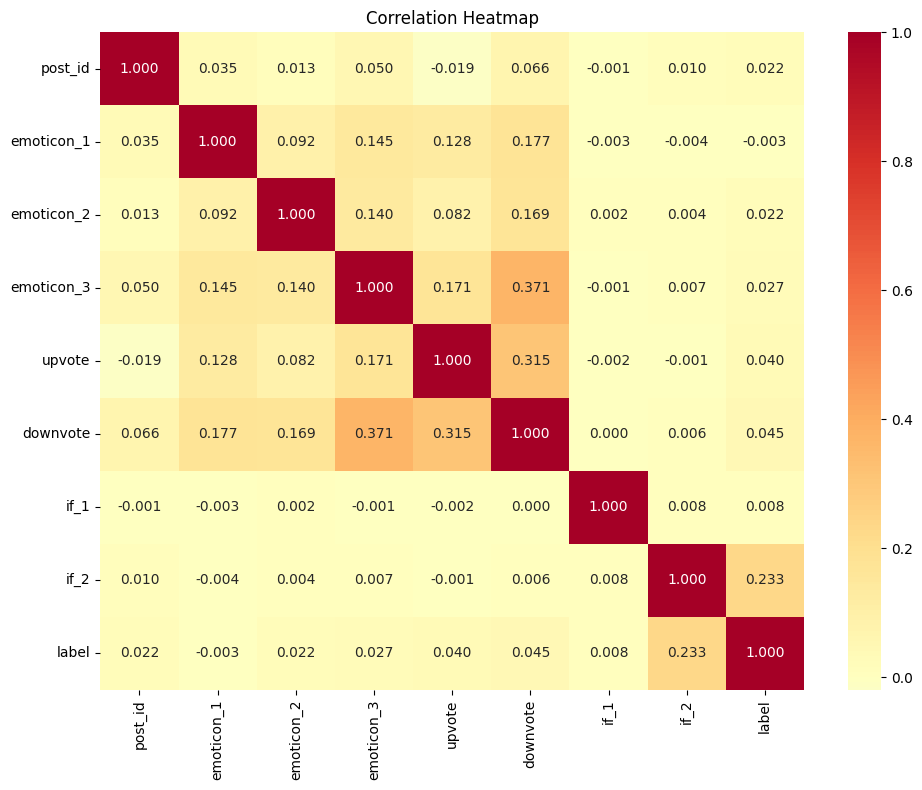


Correlation of Features with target:
if_2          0.232902
downvote      0.044908
upvote        0.040181
emoticon_3    0.027273
post_id       0.022063
emoticon_2    0.021597
if_1          0.007543
emoticon_1    0.003218
Name: label, dtype: float64


In [10]:
corr_cols = numerical_features + ['label']
corr_matrix = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0, ax=ax)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("\nCorrelation of Features with target:")
print(corr_matrix['label'].drop('label').abs().sort_values(ascending=False))

Insights

* Most numerical features have very weak correlation with the target label which means numbers alone will not predict the category well
* if_2 stands out with the highest correlation of 0.23 which suggests it carries some useful predictive signal among all numerical features
* downvote, upvote and emoticon_3 show very small positive correlations indicating only minor influence on the target
* emoticon_1, if_1 and post_id have almost negligible correlation with the label, close to zero
* There is a moderate correlation of 0.371 between downvote and emoticon_3 and 0.315 between upvote and downvote which reflects that comments with higher engagement tend to have more emoticons
* Overall low correlation values between numerical features and the label confirm that these features alone are weak predictors
* This strongly suggests that the comment text will be the most important feature for classification and text based features need to be extracted carefully

### ***Text Feature Analysis***

Text Statistics by Label:
       comment_length  word_count
label                            
0              295.90       51.19
1              335.71       57.23
2              316.89       54.90
3              194.17       34.98


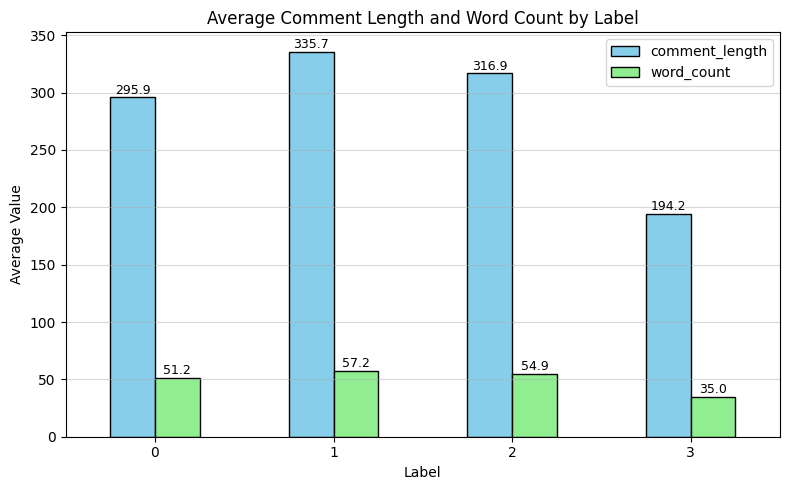

In [11]:
# Creating text features
train_df['comment_length'] = train_df['comment'].fillna('').apply(len)
train_df['word_count'] = train_df['comment'].fillna('').apply(lambda x: len(str(x).split()))

print("Text Statistics by Label:")
print(train_df.groupby('label')[['comment_length', 'word_count']].mean().round(2))

# Calculating averages for plotting
text_stats = train_df.groupby('label')[['comment_length', 'word_count']].mean()

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
text_stats.plot(kind='bar', ax=ax, color=['skyblue', 'lightgreen'], edgecolor='black')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5, f'{p.get_height():.1f}', 
            ha='center', va='bottom', fontsize=9)
plt.title('Average Comment Length and Word Count by Label')
plt.xlabel('Label')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='-', alpha=0.5)
plt.tight_layout()
plt.show()

Insights

* Label 1 comments are the longest, averaging about 336 characters and 57 words.
* Label 2 comments are slightly shorter, with around 317 characters and 55 words on average.
* Label 0 comments fall in a similar range, averaging 296 characters and about 51 words.
* Label 3 comments are noticeably shorter, with only 194 characters and around 35 words on average.
* Label 0 and Label 2 are very close in comment length which suggests their text content may overlap, making them harder to distinguish for the model
* Significant difference in Label 3 comment length indicates that comment length is a useful distinguishing feature for this class
* Overall comment length and word count vary across labels which confirms that text based features carry useful information for classification


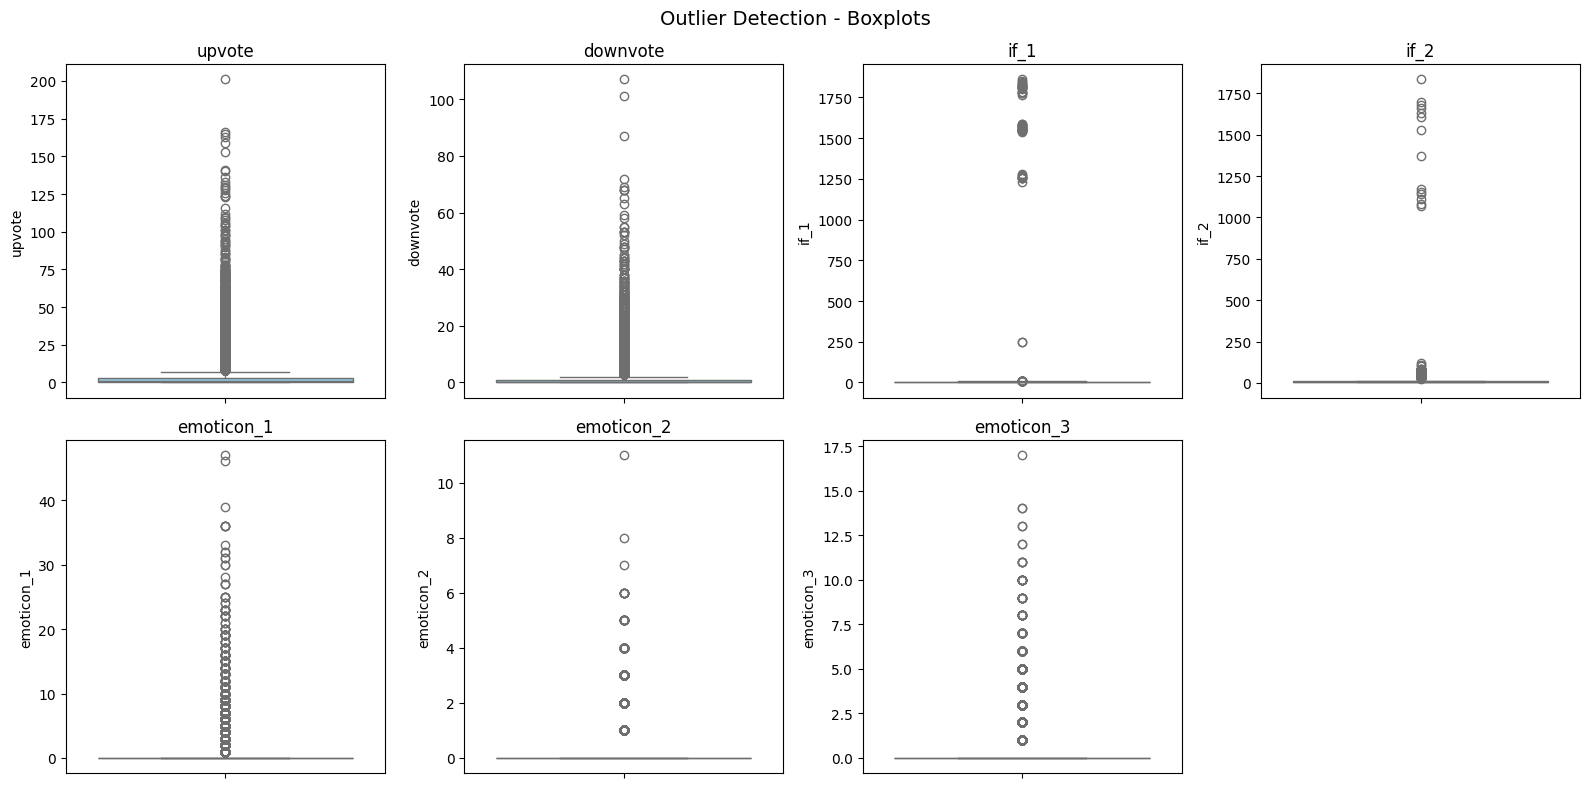

IQR Bounds for Outlier Detection:

upvote: Q1 = 0.00, Q3 = 3.00, IQR = 3.00, Lower Bound = -4.50, Upper Bound = 7.50, Outliers = 17304
downvote: Q1 = 0.00, Q3 = 1.00, IQR = 1.00, Lower Bound = -1.50, Upper Bound = 2.50, Outliers = 15173
if_1: Q1 = 0.00, Q3 = 4.00, IQR = 4.00, Lower Bound = -6.00, Upper Bound = 10.00, Outliers = 85
if_2: Q1 = 4.00, Q3 = 10.00, IQR = 6.00, Lower Bound = -5.00, Upper Bound = 19.00, Outliers = 3930
emoticon_1: Q1 = 0.00, Q3 = 0.00, IQR = 0.00, Lower Bound = 0.00, Upper Bound = 0.00, Outliers = 28922
emoticon_2: Q1 = 0.00, Q3 = 0.00, IQR = 0.00, Lower Bound = 0.00, Upper Bound = 0.00, Outliers = 8109
emoticon_3: Q1 = 0.00, Q3 = 0.00, IQR = 0.00, Lower Bound = 0.00, Upper Bound = 0.00, Outliers = 17165


In [12]:
# Outlier Detection using Boxplots
cols_to_check = ['upvote', 'downvote', 'if_1', 'if_2', 'emoticon_1', 'emoticon_2', 'emoticon_3']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(cols_to_check):
    sns.boxplot(y = train_df[col], ax = axes[idx], color = 'skyblue')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('')

# Hiding the last empty subplot (7 cols but 8 subplots)
axes[7].set_visible(False)

plt.suptitle('Outlier Detection - Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

# Printing IQR bounds for each column
print("IQR Bounds for Outlier Detection:\n")
for col in cols_to_check:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"{col}: Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}, Lower Bound = {lower:.2f}, Upper Bound = {upper:.2f}, Outliers = {outlier_count}")

Insights

* upvote and downvote have the most outliers, 17,304 and 15,173 respectively, because a small number of comments receive unusually high engagement while most get none
* if_1 has barely any outliers (85) even though its max value is 1860, meaning extreme values exist but are very isolated cases
* if_2 has 3,930 outliers which is moderate and needs to be handled before model training
* All emoticon columns show IQR of 0 because more than 75% of comments have zero emoticons, so every non zero value looks like an outlier but it is just zero inflation not a real problem
* Capping using clip() is needed for upvote, downvote and if_2 but emoticon columns should be left as is since their non zero values are genuine usage patterns not errors

# ***Data Preprocessing***

In [13]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def preprocess_data(df):
    df = df.copy()

    # Converting created_date string to datetime
    df['created_date'] = pd.to_datetime(df['created_date'])

    # Cleaning comment text — removing URLs and extra whitespace
    def clean_text(text):
        if pd.isna(text): return ''
        text = re.sub(r'http\S+|www\S+', ' ', str(text))
        return re.sub(r'\s+', ' ', text).strip()

    df['comment'] = df['comment'].apply(clean_text)

    # Filling missing values in identity columns with 'unknown'
    for col in ['race', 'religion', 'gender']:
        df[col] = df[col].fillna('unknown').replace('', 'unknown')

    # Converting disability from True/False to 1/0
    df['disability'] = df['disability'].astype(int)

    # Clipping outliers and applying log transform on engagement columns
    for col in ['upvote', 'downvote']:
        df[col] = np.log1p(df[col].clip(upper=df[col].quantile(0.99)))

    # Dropping EDA columns if they exist
    for col in ['comment_length', 'word_count']:
        if col in df.columns:
            df.drop(col, axis=1, inplace=True)

    return df

# Applying to both train and test
train_processed = preprocess_data(train_df)
test_processed  = preprocess_data(test_df)
print(f"Train shape: {train_processed.shape}")
print(f"Test shape:  {test_processed.shape}")

Train shape: (198000, 15)
Test shape:  (102000, 14)


In [14]:
# Separating features after cleaning — dropping label, comment and created_date
X = train_processed.drop(['label', 'comment', 'created_date'], axis=1)
y = train_processed['label']
X_test = test_processed.drop(['comment', 'created_date'], axis=1)

# Identifying numerical and categorical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Numerical columns:   {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

# Numerical pipeline — imputing with median and scaling
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline — imputing and one hot encoding
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combining both pipelines into one preprocessor
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("\nPreprocessing pipeline created successfully")

Numerical columns:   ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability']
Categorical columns: ['race', 'religion', 'gender']

Preprocessing pipeline created successfully


# ***Feature Engineering***

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# Keeping comment separately for TF-IDF
comments_train = train_processed['comment']
comments_test  = test_processed['comment']

# Encoding target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target classes: {le.classes_}")
print(f"Encoded labels: {np.unique(y_encoded)}")

# TF-IDF Vectorizer
tfidf_word = TfidfVectorizer(max_features=6000, ngram_range=(1, 2),min_df=3,max_df=0.90,sublinear_tf=True)

tfidf_char = TfidfVectorizer(max_features=1000, ngram_range=(2, 3), min_df=10, max_df=0.90, sublinear_tf=True, analyzer='char_wb')
# Fitting on train text and transforming test text
tfidf_word_train = tfidf_word.fit_transform(comments_train)
tfidf_word_test  = tfidf_word.transform(comments_test)
tfidf_char_train = tfidf_char.fit_transform(comments_train)
tfidf_char_test  = tfidf_char.transform(comments_test)

print(f"Word TF-IDF features:  {tfidf_word_train.shape[1]}")
print(f"Char TF-IDF features:  {tfidf_char_train.shape[1]}")
print(f"Total TF-IDF features: {tfidf_word_train.shape[1] + tfidf_char_train.shape[1]}")

Target classes: [0 1 2 3]
Encoded labels: [0 1 2 3]
Word TF-IDF features:  6000
Char TF-IDF features:  1000
Total TF-IDF features: 7000


In [16]:
# Splitting into 80% train and 20% validation with stratification
(X_train, X_val, y_train, y_val, comm_train, comm_val, y_train_enc, y_val_enc) = train_test_split(
    X, y, comments_train, y_encoded,
    test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Fitting preprocessor on train and transforming all splits
X_train_structured = preprocessor.fit_transform(X_train)
X_val_structured   = preprocessor.transform(X_val)
X_test_structured  = preprocessor.transform(X_test)

# Splitting TF-IDF matrices to match train and val indices
tfidf_word_tr = tfidf_word_train[X_train.index]
tfidf_word_vl = tfidf_word_train[X_val.index]
tfidf_char_tr = tfidf_char_train[X_train.index]
tfidf_char_vl = tfidf_char_train[X_val.index]

# Combining structured features with TF-IDF features
X_train_combined = hstack([csr_matrix(X_train_structured), tfidf_word_tr, tfidf_char_tr])
X_val_combined   = hstack([csr_matrix(X_val_structured),   tfidf_word_vl, tfidf_char_vl])
X_test_combined  = hstack([csr_matrix(X_test_structured),  tfidf_word_test, tfidf_char_test])

print(f"Combined train features: {X_train_combined.shape[1]}")
print(f"Combined val features:   {X_val_combined.shape[1]}")
print(f"Combined test features:  {X_test_combined.shape[1]}")

Training samples:   158400
Validation samples: 39600
Combined train features: 7031
Combined val features:   7031
Combined test features:  7031


# ***Model Training***

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs',
        random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'Linear SVM': LinearSVC(
        max_iter=1000, C=0.5, loss='hinge', tol=1e-3,
        random_state=42, dual='auto', class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        tree_method='hist', n_estimators=400,
        max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        random_state=42, n_jobs=-1, eval_metric='mlogloss'
    ),
}

In [18]:
results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}")
    
    # Fitting model
    model.fit(X_train_combined, y_train)
    trained_models[name] = model
    
    # Training score
    train_pred = model.predict(X_train_combined)
    train_acc = accuracy_score(y_train, train_pred)
    
    # Validation score
    val_pred = model.predict(X_val_combined)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1 = f1_score(y_val, val_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Val Acc': val_acc,
        'f1_Score': val_f1,
    })
    
    print(f" Train: {train_acc:.4f} | Val: {val_acc:.4f} | f1_score: {val_f1:.4f}")


Training Logistic Regression
 Train: 0.9069 | Val: 0.8884 | f1_score: 0.8953

Training Linear SVM
 Train: 0.9102 | Val: 0.8975 | f1_score: 0.9009

Training XGBoost
 Train: 0.9266 | Val: 0.9081 | f1_score: 0.9062


Insights
* All three models perform well with validation F1 scores above 0.89 which is strong for a 4 class imbalanced problem
* XGBoost leads with the highest validation F1 of 0.9062 followed by Linear SVM at 0.9009 and Logistic Regression at 0.8953
* The small gap between train and validation scores across all models shows they are generalising well without significant overfitting
* Logistic Regression despite being the simplest model still achieves a solid validation accuracy of 0.8884 showing that the features carry strong linear signal

# ***Hyperparameter Tuning***

In [19]:
from sklearn.model_selection import RandomizedSearchCV
print("Tuning Logistic Regression")
lr_params = {
    'C': [0.5],  #[0.5, 1.0],
    'solver': ['lbfgs'],  #['lbfgs', 'saga'],
    'max_iter': [2000],     #[2000, 3000],
    'penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42, n_jobs=-1, class_weight='balanced', multi_class='multinomial'),
    lr_params, n_iter=5, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
lr_search.fit(X_train_combined, y_train)

lr_best_pred = lr_search.best_estimator_.predict(X_val_combined)
lr_best_f1 = f1_score(y_val, lr_best_pred, average='weighted')
print(f"Best Logistic Regression F1 Score (Val): {lr_best_f1:.4f}")
# print(f"Best Logistic Regression Params: {lr_search.best_params_}")

Tuning Logistic Regression
Best Logistic Regression F1 Score (Val): 0.8957


In [20]:
print("Tuning Linear SVM")
svm_params = {
    'C': [0.5],    #[0.1, 0.5, 1.0],
    'loss': ['hinge'],  #['hinge', 'squared_hinge'],
    'tol': [0.0001]  #[1e-3, 1e-4]
}
svm_search = RandomizedSearchCV(
    LinearSVC(class_weight='balanced', max_iter=1000, random_state=42, dual='auto'),
    svm_params, n_iter=5, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
svm_search.fit(X_train_combined, y_train)

svm_best_pred = svm_search.best_estimator_.predict(X_val_combined)
svm_best_f1 = f1_score(y_val, svm_best_pred, average='weighted')
print(f"Best Linear SVM F1 Score (Val): {svm_best_f1:.4f}")
# print(f"Best Linear SVM Params: {svm_search.best_params_}")

Tuning Linear SVM
Best Linear SVM F1 Score (Val): 0.9009


In [21]:
print("Tuning XGBoost")
xgb_params = {
    'n_estimators': [400],   #[300,400],
    'max_depth': [6],         #[6,8],
    'learning_rate': [0.1],  #[0.05, 0.1],
    'subsample': [0.7],      #[0.7, 0.8],
    'reg_alpha': [0.5],     #[0.1, 0.5],
    'reg_lambda': [0.05],    #[0.05, 0.1]
    'min_child_weight': [1], #[1, 3]
    'gamma': [0.1]  #[0, 0.1]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(tree_method='hist', random_state=42, n_jobs=-1, eval_metric="mlogloss", colsample_bytree=0.8),
    xgb_params, n_iter=5, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
xgb_search.fit(X_train_combined, y_train)

xgb_best_pred = xgb_search.best_estimator_.predict(X_val_combined)
xgb_best_f1 = f1_score(y_val, xgb_best_pred, average='weighted')
print(f"Best XGBoost F1 Score (Val): {xgb_best_f1:.4f}")
# print(f"Best XGBoost Params: {xgb_search.best_params_}")

Tuning XGBoost
Best XGBoost F1 Score (Val): 0.9102


# ***Model Comparison***


Model Comparison Results:
              Model  F1 Score
            XGBoost  0.910181
         Linear SVM  0.900891
Logistic Regression  0.895678


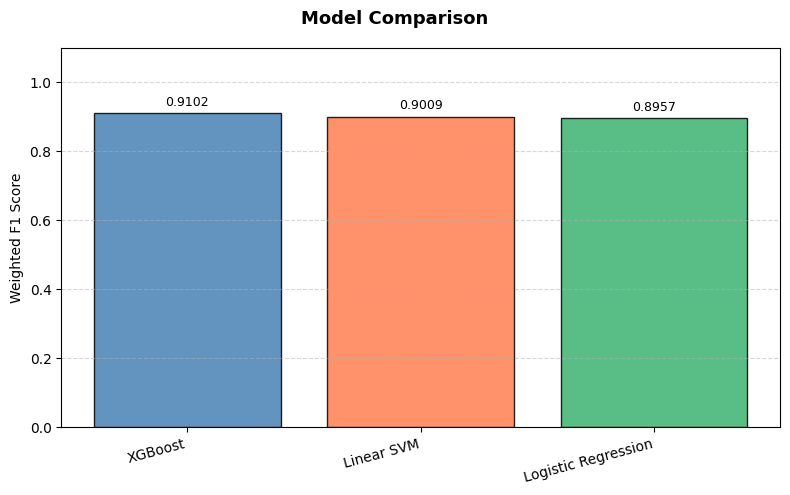

In [22]:
# Comparison Table
final_results = pd.DataFrame([
    {'Model': 'Logistic Regression','F1 Score': lr_best_f1},
    {'Model': 'Linear SVM','F1 Score': svm_best_f1},
    {'Model': 'XGBoost','F1 Score': xgb_best_f1}
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('\nModel Comparison Results:')
print(final_results.to_string(index=False))

# Visualization of Model Comparison
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Model Comparison', fontsize=13, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen']
bars = ax.bar(final_results['Model'], final_results['F1 Score'],
              color=colors[:len(final_results)], alpha=0.85, edgecolor='black')

ax.set_ylabel('Weighted F1 Score')
ax.set_xticklabels(final_results['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

Insights
* After hyperparameter tuning XGBoost remains the best model with an F1 score of 0.9102 followed by Linear SVM at 0.9009 and Logistic Regression at 0.8957
* The tuned scores are very close to the baseline scores which confirms that the initial parameters were already well chosen and tuning provided only marginal improvement
* All three models are within about 1.5% of each other showing that the features are strong and consistent across all model types

In [23]:
# Selecting best model
best_model_name = final_results.iloc[0]['Model']

if 'Logistic Regression' in best_model_name:
    final_model = lr_search.best_estimator_
    final_pred  = lr_best_pred
elif 'Linear SVM' in best_model_name:
    final_model = svm_search.best_estimator_
    final_pred  = svm_best_pred
else:
    final_model = xgb_search.best_estimator_
    final_pred  = xgb_best_pred

print(f"\nBest Model: {best_model_name}")


Best Model: XGBoost


Classification Report:
              precision    recall  f1-score   support

     Label 0       0.98      0.95      0.96     22835
     Label 1       0.78      0.76      0.77      3183
     Label 2       0.84      0.92      0.88     12488
     Label 3       0.77      0.45      0.57      1094

    accuracy                           0.91     39600
   macro avg       0.84      0.77      0.80     39600
weighted avg       0.91      0.91      0.91     39600



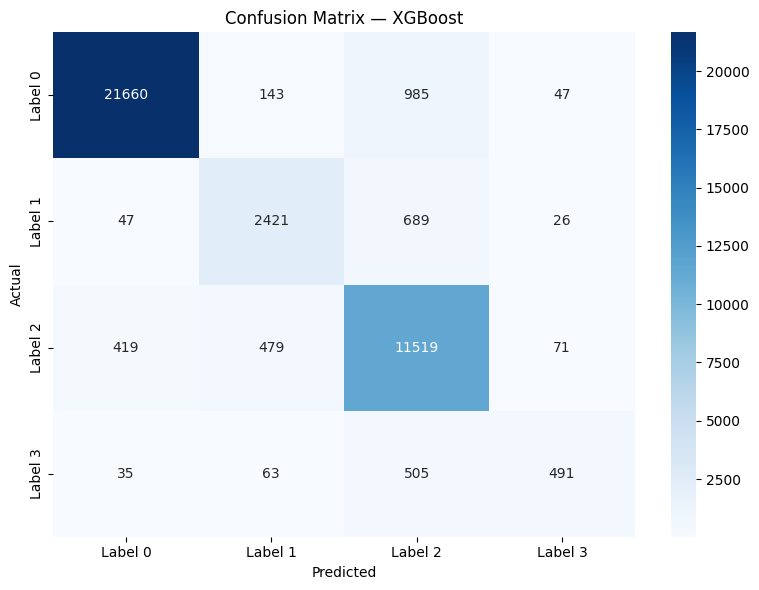

In [24]:
# Classification report
print("Classification Report:")
print(classification_report(y_val, final_pred, target_names=['Label 0', 'Label 1', 'Label 2', 'Label 3']))


# Confusion Matrix
cm = confusion_matrix(y_val, final_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Label 0', 'Label 1', 'Label 2', 'Label 3'],
            yticklabels=['Label 0', 'Label 1', 'Label 2', 'Label 3'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

Insights
* Label 0 achieves the highest F1 score of 0.96 because it holds the majority of training data giving the model sufficient examples to learn strong decision boundaries
* Label 3 has the lowest F1 score of 0.57 due to severe class imbalance representing only 2.76% of the data which limits the model ability to learn its patterns
* Label 3 recall is only 0.45 which means out of every 10 actual Label 3 comments the model correctly identifies only 4 to 5 and misses the rest
* Label 1 and Label 2 show cross confusion with 689 Label 1 comments misclassified as Label 2 suggesting these two categories share overlapping text patterns
* Label 3 is most confused with Label 2 where 505 actual Label 3 comments were predicted as Label 2 indicating similar linguistic patterns between these two categories
* Overall accuracy of 0.91 looks strong but the macro average F1 of 0.80 is a more honest measure as it treats all 4 classes equally regardless of their size

# ***Model Evaluation***

In [25]:
# Fitting preprocessor and TF-IDF on full training data for final prediction
X_full_structured = preprocessor.fit_transform(X)
tfidf_word_full = tfidf_word.fit_transform(comments_train)
tfidf_char_full = tfidf_char.fit_transform(comments_train)

# Combining structured and TF-IDF features
X_full_combined = hstack([csr_matrix(X_full_structured), tfidf_word_full, tfidf_char_full])

# Training all three tuned models on full training data
model1 = xgb_search.best_estimator_
model2 = svm_search.best_estimator_
model3 = lr_search.best_estimator_

model1.fit(X_full_combined, y)
model2.fit(X_full_combined, y)
model3.fit(X_full_combined, y)

# Preparing test features using same fitted transformers
X_test_final = hstack([
    csr_matrix(preprocessor.transform(X_test)),
    tfidf_word.transform(comments_test),
    tfidf_char.transform(comments_test)
])

# Getting probability predictions from XGBoost and Logistic Regression
pred1 = model1.predict_proba(X_test_final)
pred3 = model3.predict_proba(X_test_final)

# Converting LinearSVC decision scores to probabilities using softmax
decision_scores = model2.decision_function(X_test_final)
decision_scores = decision_scores - decision_scores.max(axis=1, keepdims=True)
pred2 = np.exp(decision_scores) / np.exp(decision_scores).sum(axis=1, keepdims=True)

# Weighted ensemble — XGBoost weighted highest as it performed best
final_probs = (0.60 * pred1) + (0.25 * pred2) + (0.15 * pred3)
test_predictions = np.argmax(final_probs, axis=1)

print(f"Test predictions shape: {test_predictions.shape}")
print(f"Unique predicted labels: {np.unique(test_predictions)}")

Test predictions shape: (102000,)
Unique predicted labels: [0 1 2 3]


# ***Submission***

In [26]:
submission = pd.DataFrame({
    'ID'   : sample_submission["ID"],
    'label': test_predictions
})
submission.to_csv('submission.csv', index=False)
print(f"Submission created: {len(submission)} predictions")
print(f"\nPrediction distribution:\n{submission['label'].value_counts()}")

Submission created: 102000 predictions

Prediction distribution:
label
0    56825
2    34684
1     8319
3     2172
Name: count, dtype: int64


In [27]:
submission.head(10)

,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2


Finall Insights from the notebook

**About Data**
* Dataset has 198,000 training and 102,000 test comments with 15 columns covering text, numerical, categorical and datetime features
* Target variable label can take 4 distinct values representing different internal comment handling categories

**EDA**
* Target variable is heavily imbalanced with Label 0 dominating at 57.66% and Label 3 being the rarest at only 2.76%
* race, religion and gender have exactly 73.45% missing values each indicating they are generated together by the same internal detection system
* Most numerical features are heavily right skewed with extreme outliers especially in if_1 and if_2
* if_2 is the only numerical feature with a meaningful correlation of 0.23 with the target confirming that text will be the most important signal
* Label 3 comments are noticeably shorter at 194 characters on average compared to other labels suggesting comment length is a useful distinguishing feature

**Preprocessing**
* Missing values in race, religion and gender were filled with unknown and disability was converted from boolean to binary
* URLs were removed from comments and extra whitespace was cleaned before model training
* upvote and downvote were clipped at 99th percentile and log transformed to handle extreme skewness

**Feature Engineering**
* Two TF-IDF vectorizers were used, word level with 6000 features capturing words and phrases and character level with 1000 features capturing subword patterns giving 7000 total text features
* Combining structured features with both TF-IDF matrices resulted in 7031 total features per sample
* Target labels were encoded using LabelEncoder before model training

**Model Building**
* Three models were trained, XGBoost, Linear SVM and Logistic Regression on a combined feature matrix of 7031 features
* class_weight=balanced was used in Linear SVM and Logistic Regression to handle class imbalance
* XGBoost led with validation F1 of 0.9062 followed by Linear SVM at 0.9009 and Logistic Regression at 0.8953 in baseline training

**Hyperparameter Tuning**
* RandomizedSearchCV with 3 fold cross validation was used to tune all three models
* Best parameters were identified manually through multiple experiments before finalising
* Tuning was done using weighted F1 score as the evaluation metric to account for class imbalance
* After tuning XGBoost improved to 0.9102 showing the most gain from tuning

**Model Comparison**
* After tuning XGBoost remained the best model with F1 of 0.9102 followed by Linear SVM at 0.9009 and Logistic Regression at 0.8957
* All three models are within 1.5% of each other confirming that the features are strong and consistent across all model types
* XGBoost was selected as the best model

**Model Evaluation**
* Label 0 achieves the highest F1 of 0.96 due to having the most training samples at 57.66%
* Label 3 has the lowest F1 of 0.57 due to severe class imbalance with only 2.76% of data
* Label 3 recall is only 0.45 meaning the model misses more than half of actual Label 3 comments
* Label 1 and Label 2 are frequently confused with each other with 689 Label 1 comments misclassified as Label 2 due to overlapping text patterns
* Overall accuracy is 0.91 but macro F1 of 0.80 gives a fairer picture by treating all classes equally

**Final Predictions**
* All three tuned models were retrained on full training data and combined using a weighted ensemble of 0.60 XGBoost, 0.25 Linear SVM and 0.15 Logistic Regression
* LinearSVC does not support predict_proba so its decision function scores were converted to probabilities using softmax
* Final submission contains 102,000 predictions covering all four label categories